In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1 

### 1.

In [34]:
df = pd.read_csv("daily_sales.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["product_id", "date"])

df.head()

,product_id,date,sales
0,P001,2023-01-01,56
1,P001,2023-01-02,35
2,P001,2023-01-03,44
3,P001,2023-01-04,45
4,P001,2023-01-05,30


In [35]:
df["mean_sales"] = df.groupby("product_id")["sales"].transform("mean")
df["std_sales"] = df.groupby("product_id")["sales"].transform("std")

df["z_score"] = ( (df["sales"] - df["mean_sales"]) /  df["std_sales"])

df.head()

,product_id,date,sales,mean_sales,std_sales,z_score
0,P001,2023-01-01,56,62.223594,369.289477,-0.016853
1,P001,2023-01-02,35,62.223594,369.289477,-0.073719
2,P001,2023-01-03,44,62.223594,369.289477,-0.049348
3,P001,2023-01-04,45,62.223594,369.289477,-0.046640
4,P001,2023-01-05,30,62.223594,369.289477,-0.087258


### 2.

In [36]:
df["anomaly_z3"] = df["z_score"].abs() > 3

anomaly_counts = (
    df.groupby("product_id")["anomaly_z3"]
      .sum()
      .astype(int)
)

print(anomaly_counts)

product_id
P001    1
P002    1
P003    3
P004    1
Name: anomaly_z3, dtype: int64


### 3. 

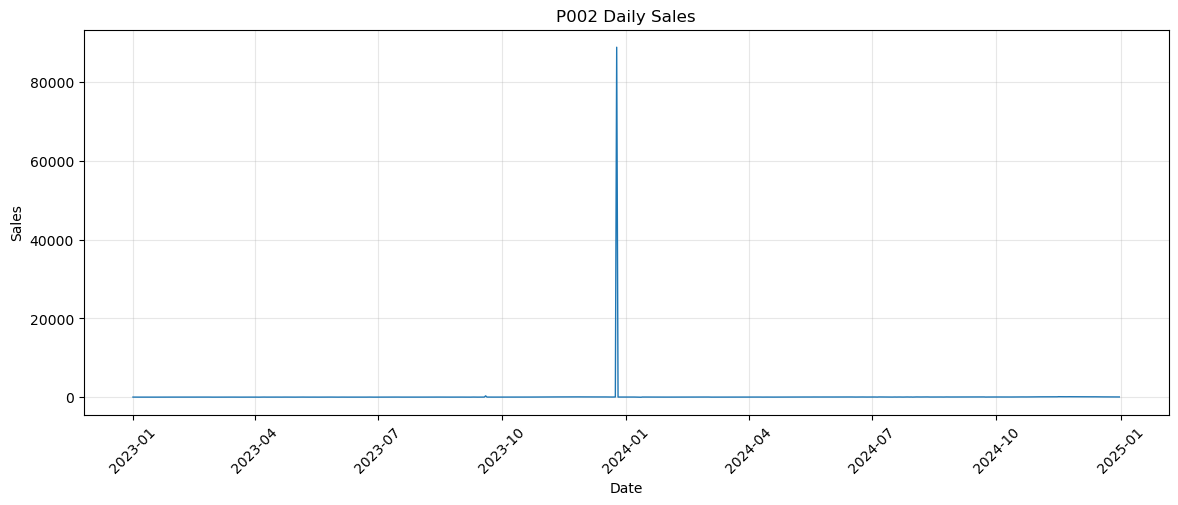

In [37]:
p002 = df[df["product_id"] == "P002"]

plt.figure(figsize=(14, 5))

plt.plot(
    p002["date"],
    p002["sales"],
    linewidth=1
)

plt.title("P002 Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

In [38]:
p002["sales"].describe()

count      732.000000
mean       169.043716
std       3283.732555
min          0.000000
25%         31.000000
50%         40.000000
75%         57.000000
max      88888.000000
Name: sales, dtype: float64

In [39]:
shift_date = pd.Timestamp("2024-05-01")

p002_before = p002[p002["date"] < shift_date]
p002_after = p002[p002["date"] >= shift_date]

In [40]:
comparison = pd.DataFrame({
    "Period": [
        "Full Period",
        "Before Shift",
        "After Shift"
    ],
    "Mean": [
        p002["sales"].mean(),
        p002_before["sales"].mean(),
        p002_after["sales"].mean()
    ],
    "Standard Deviation": [
        p002["sales"].std(),
        p002_before["sales"].std(),
        p002_after["sales"].std()
    ],
    "Number of Records": [
        len(p002),
        len(p002_before),
        len(p002_after)
    ]
})

comparison

,Period,Mean,Standard Deviation,Number of Records
0,Full Period,169.043716,3283.732555,732
1,Before Shift,220.076132,4030.398846,486
2,After Shift,68.223577,23.700056,246


Why does the global Z-score fail?
* The global Z-score uses Entire P002 dataset, One mean, One standard deviation, Calculate every Z-score. 
* But P002 actually has two different behaviors: Before shift(lower typical sales) and an After shift(higher typical sales)
* Conclusion: A global Z-score can miss a sustained level shift because the new regime becomes part of the baseline.

### 4. 

In [43]:
p003 = df[df["product_id"] == "P003"]

p003["sales"].describe()

count    728.000000
mean       1.740385
std        2.268113
min       -5.000000
25%        0.000000
50%        0.000000
75%        4.000000
max       10.000000
Name: sales, dtype: float64

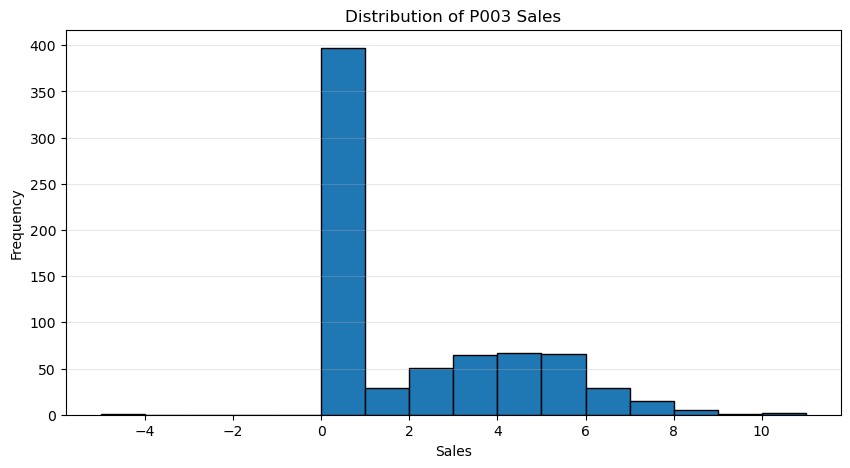

In [44]:
plt.figure(figsize=(10, 5))

plt.hist(
    p003["sales"],
    bins=range(
        int(p003["sales"].min()),
        int(p003["sales"].max()) + 2
    ),
    edgecolor="black"
)

plt.title("Distribution of P003 Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [45]:
p003_anomalies = p003[p003["z_score"].abs() > 3]

p003_anomalies[
    ["date", "sales", "z_score"]
]

,date,sales,z_score
2049,2024-08-14,10,3.641624
2138,2024-11-11,9,3.200729
2162,2024-12-05,10,3.641624


P003 has a highly skewed, zero-inflated distribution rather than a normal distribution. Therefore, the mean and standard deviation do not describe the distribution very well. The Z-score method flags a few high-sales observations, but these may not represent genuine anomalies. This demonstrates that Z-score detection can produce misleading results when the underlying data is highly skewed or contains many structural zeros.

### 5.

In [46]:
thresholds = [2, 3, 4]

for threshold in thresholds:
    df[f"anomaly_z{threshold}"] = (
        df["z_score"].abs() > threshold
    )

In [47]:
threshold_results = pd.DataFrame({
    "Z-score Threshold": [2, 3, 4],
    "P001": [
        df[df["product_id"] == "P001"]["anomaly_z2"].sum(),
        df[df["product_id"] == "P001"]["anomaly_z3"].sum(),
        df[df["product_id"] == "P001"]["anomaly_z4"].sum()
    ],
    "P002": [
        df[df["product_id"] == "P002"]["anomaly_z2"].sum(),
        df[df["product_id"] == "P002"]["anomaly_z3"].sum(),
        df[df["product_id"] == "P002"]["anomaly_z4"].sum()
    ],
    "P003": [
        df[df["product_id"] == "P003"]["anomaly_z2"].sum(),
        df[df["product_id"] == "P003"]["anomaly_z3"].sum(),
        df[df["product_id"] == "P003"]["anomaly_z4"].sum()
    ],
    "P004": [
        df[df["product_id"] == "P004"]["anomaly_z2"].sum(),
        df[df["product_id"] == "P004"]["anomaly_z3"].sum(),
        df[df["product_id"] == "P004"]["anomaly_z4"].sum()
    ]
})

threshold_results

,Z-score Threshold,P001,P002,P003,P004
0,2,1,1,24,23
1,3,1,1,3,1
2,4,1,1,0,1


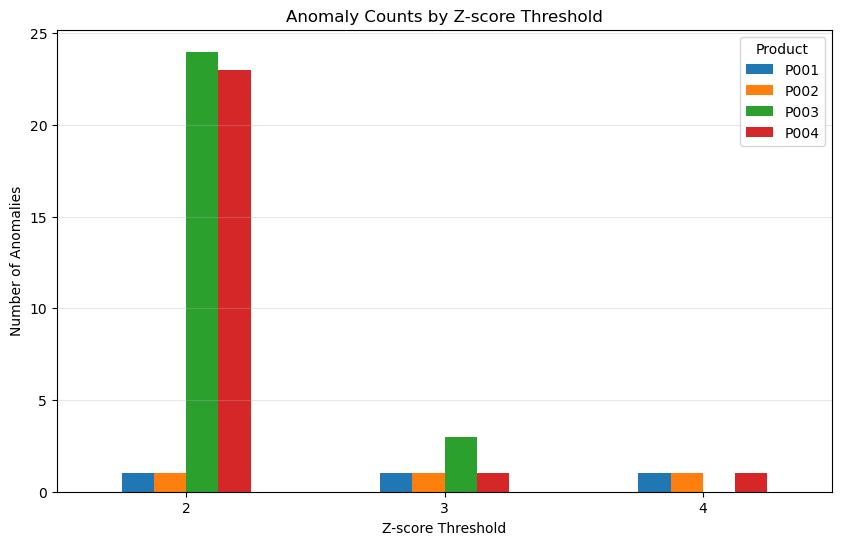

In [48]:
threshold_results.set_index("Z-score Threshold").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Anomaly Counts by Z-score Threshold")
plt.xlabel("Z-score Threshold")
plt.ylabel("Number of Anomalies")
plt.xticks(rotation=0)
plt.legend(title="Product")
plt.grid(axis="y", alpha=0.3)

plt.show()

,Product,Z > 2,Z > 3,Z > 4
0,P001,1,1,1
1,P002,1,1,1
2,P003,24,3,0
3,P004,23,1,1


Findings

* P001 barely changes: Its extreme value remains unusual regardless of threshold  
* P002 only has 1 candidate: the huge standard deviation makes global Z-scores weak     
* P003 changes dramatically: z-score is sensitive to its skewed/zero-heavy distribution 
* P004 changes dramatically: threshold choice strongly affects detected anomalies       


### Exercise 1 Conclusion
* Z-score is simple and useful for detecting extreme observations, but it assumes that the data has a reasonably stable and symmetric distribution. In this dataset, P002 demonstrates the problem with using a global baseline when the normal sales level changes over time. The large outlier in P002 also inflates the standard deviation, making other unusual observations harder to detect. P003 demonstrates another limitation because its sales distribution contains many zeros and is strongly skewed, so Z-score flags rare high values that may not necessarily be true anomalies. Finally, changing the threshold from 2 to 3 or 4 produces very different numbers of candidates, showing that Z-score anomaly detection can be highly sensitive to the chosen threshold.

## Exercise 2 

### 1.

In [54]:
df["median_sales"] = ( df.groupby("product_id")["sales"].transform("median"))

df["mad_sales"] = (
    df.groupby("product_id")["sales"]
      .transform(
          lambda x: np.median(
              np.abs(x - np.median(x))
          )
      )
)

### 2.

* P003 contains a lot of zero sales, so its median = 0 MAD = 0 and would reqiure dividing by zero
* MAD-based detection also has limitations when a variable has extremely concentrated values, such as P003s many zero-sales days

In [55]:
df["modified_z"] = np.where(
    df["mad_sales"] == 0,
    np.nan,
    0.6745 *
    (df["sales"] - df["median_sales"]) /
    df["mad_sales"]
)

df["mad_anomaly"] = (
    df["modified_z"].abs() > 3.5
)

### 3.

In [56]:
mad_counts = (
    df.groupby("product_id")["mad_anomaly"]
      .sum()
      .astype(int)
)

mad_counts

product_id
P001     9
P002    36
P003     0
P004     1
Name: mad_anomaly, dtype: int64

### 4.

In [58]:
mad_anomalies = df[df["mad_anomaly"]]

mad_anomalies[
    [
        "product_id",
        "date",
        "sales",
        "median_sales",
        "mad_sales",
        "modified_z"
    ]
]

mad_anomalies.sort_values(
    "modified_z",
    key=abs,
    ascending=False
)[
    [
        "product_id",
        "date",
        "sales",
        "modified_z"
    ]
]

,product_id,date,sales,modified_z
1087,P002,2023-12-25,88888,4993.998000
219,P001,2023-08-08,9999,1118.883083
548,P001,2024-07-02,490,49.913000
72,P001,2023-03-14,432,43.392833
990,P002,2023-09-19,342,16.974917
2612,P004,2024-02-27,192,8.197769
1422,P002,2024-11-23,137,5.452208
1415,P002,2024-11-16,136,5.396000
158,P001,2023-06-08,0,-5.171167
155,P001,2023-06-05,0,-5.171167


We're going to take the extreme value out and see what happens to:
Mean, Standard deviation, Median, MAD
lets take a look at p001

### 5.

In [59]:
p001 = df[df["product_id"] == "P001"].copy()

extreme_index = p001["sales"].idxmax()

p001.loc[
    extreme_index,
    ["date", "sales"]
] 

date     2023-08-08 00:00:00
sales                   9999
Name: 219, dtype: object

In [60]:
p001_sales = p001["sales"]

p001_without = p001_sales.drop(extreme_index)

mean_before = p001_sales.mean()
mean_after = p001_without.mean()

std_before = p001_sales.std()
std_after = p001_without.std()

median_before = p001_sales.median()
median_after = p001_without.median()

mad_before = np.median(
    np.abs(p001_sales - median_before)
)

mad_after = np.median(
    np.abs(p001_without - median_after)
)

print("Mean:", mean_before, "→", mean_after)
print("Std:", std_before, "→", std_after)
print("Median:", median_before, "→", median_after)
print("MAD:", mad_before, "→", mad_after)

Mean: 62.223593964334704 → 48.574175824175825
Std: 369.2894769611073 → 23.62120822479886
Median: 46.0 → 46.0
MAD: 6.0 → 6.0


Exercise 2 conclusion 
* Modified Z-score is more robust than the ordinary Z-score because it uses the median and MAD instead of the mean and standard deviation. In this dataset, the extreme values 9,999 for P001 and 88,888 for P002 greatly increased the mean and standard deviation, while the median and MAD remained unchanged when those values were removed. This demonstrates that median and MAD are less affected by extreme observations. The comparison also showed that Modified Z-score detected more anomalies for P001 and P002 because the extreme values did not inflate the MAD in the same way that they inflated the standard deviation. However, Modified Z-score still has a limitation: it uses one global median and MAD for the whole time period, so it may not reliably detect sustained changes in the normal level of a product, such as the level shift in P002.

## Exercise 3 

### 1. 

In [61]:
from sklearn.neighbors import NearestNeighbors

df["knn_distance"] = np.nan

for product, group in df.groupby("product_id"):

    X = group[["sales"]]
    knn = NearestNeighbors(n_neighbors=6)

    knn.fit(X)

    distances, indices = knn.kneighbors(X)

    # First neighbor is the point itself, so remove it
    avg_distance = distances[:, 1:].mean(axis=1)

    df.loc[group.index, "knn_distance"] = avg_distance

### 2.

In [62]:
df["knn_anomaly"] = False

for product, group in df.groupby("product_id"):

    threshold = group["knn_distance"].quantile(0.97)

    df.loc[group.index, "knn_anomaly"] = (
        group["knn_distance"] >= threshold
    )

df.groupby("product_id")["knn_anomaly"].sum()

product_id
P001     24
P002     23
P003    728
P004     22
Name: knn_anomaly, dtype: int64

### 3.

In [64]:
comparison_knn = pd.DataFrame({
    "Product": sorted(df["product_id"].unique()),

    "Z-score > 3": [
        df[df["product_id"] == p]["anomaly_z3"].sum()
        for p in sorted(df["product_id"].unique())
    ],

    "Modified Z-score > 3.5": [
        df[df["product_id"] == p]["mad_anomaly"].sum()
        for p in sorted(df["product_id"].unique())
    ],

    "Univariate KNN": [
        df[df["product_id"] == p]["knn_anomaly"].sum()
        for p in sorted(df["product_id"].unique())
    ]
})

comparison_knn

,Product,Z-score > 3,Modified Z-score > 3.5,Univariate KNN
0,P001,1,9,24
1,P002,1,36,23
2,P003,3,0,728
3,P004,1,1,22


Modified Z-score asks: "How far is this value from the median?"
KNN asks:"How far is this value from its nearest sales values?"

### 4.

In [65]:
df["sales_lag_1"] = (
    df.groupby("product_id")["sales"].shift(1)
)

df["sales_lag_7"] = (
    df.groupby("product_id")["sales"].shift(7)
)

df["rolling_mean_7"] = (
    df.groupby("product_id")["sales"]
      .transform(
          lambda x: x.shift(1).rolling(7).mean()
      )
)

df["day_of_week"] = df["date"].dt.dayofweek

features = [
    "sales",
    "sales_lag_1",
    "sales_lag_7",
    "rolling_mean_7",
    "day_of_week"
]

### 5. 

In [66]:
from sklearn.preprocessing import StandardScaler

df_knn = df.dropna(subset=features).copy()

df_knn["knn_multi_distance"] = np.nan

for product, group in df_knn.groupby("product_id"):

    X = group[features]

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    knn = NearestNeighbors(n_neighbors=6)

    knn.fit(X_scaled)

    distances, indices = knn.kneighbors(X_scaled)

    avg_distance = distances[:, 1:].mean(axis=1)

    df_knn.loc[group.index, "knn_multi_distance"] = avg_distance

### 6. 

In [67]:
df_knn["knn_multi_anomaly"] = False

for product, group in df_knn.groupby("product_id"):

    threshold = group["knn_multi_distance"].quantile(0.97)

    df_knn.loc[group.index, "knn_multi_anomaly"] = (
        group["knn_multi_distance"] >= threshold
    )

df_knn.groupby("product_id")["knn_multi_anomaly"].sum()

product_id
P001    22
P002    22
P003    22
P004    22
Name: knn_multi_anomaly, dtype: int64

Practical trade-off

Method               Main choices/parameters     

* Z-score: Mean, std, threshold `3` 
* Modified Z-score: Median, MAD, threshold `3.5` 
* Multivariate KNN: Features, `k=5`, scaling, top 3% threshold


Exercise 3 conclusion 
* KNN provides a different approach to anomaly detection because it judges each observation based on its nearest neighbors rather than its distance from one global mean or median. In the univariate case, KNN using only sales can behave somewhat similarly to Modified Z-score because both identify unusual sales values, but KNN focuses on local density. Multivariate KNN is more powerful because it can use sales, previous-day sales, previous-week sales, recent average sales, and day of week together. This allows it to identify contextual anomalies where a sales value may look normal by itself but does not fit the recent pattern. However, KNN requires more choices, such as selecting features, choosing k, scaling the data, and selecting an anomaly threshold. For a live monitoring system, I would prefer a simpler and more explainable robust method, while using multivariate KNN mainly for deeper offline investigation.

## Exericse 4 

### 1. 

anomaly_answer_key.csv was not provided 

### 2. 

### 3. 

### 4. 

### 5. 